# **Snow-Cover Delineation and Change Detection using Landsat 8 and DEM Integration**

This notebook presents a Python-based geospatial remote-sensing workflow for snow-cover delineation and temporal change detection using Landsat 8 imagery and DEM integration.

The workflow combines NDSI-based snow extraction, cloud masking, DEM-assisted classification, and morphological image processing to evaluate snow-cover dynamics between 2013 and 2022.

---
## Study Area

The study focuses on the **Siachen Glacier region** in the northwestern Himalaya–Karakoram terrain. The region is characterized by high-altitude snow and glacier systems, making it suitable for snow-cover and elevation-dependent cryospheric analysis.

----
## Workflow Overview

The workflow includes:

1. Surface reflectance preprocessing of Landsat 8 imagery  
2. DEM alignment and spatial reprojection  
3. Cloud and cloud-shadow masking using QA_PIXEL bands  
4. NDSI computation and multi-criteria snow delineation  
5. Morphological filtering for spatial refinement  
6. Snow-cover area estimation  
7. Temporal snow-change detection  
8. Elevation-wise snow-distribution analysis  
9. Scientific visualization and figure generation  

---

## Datasets Used

### Landsat 8 Level-2 Surface Reflectance Data
- Green Band (Band 3)
- SWIR Band (Band 6)
- QA_PIXEL Band

### Digital Elevation Model (DEM)
- SRTM 30 m DEM

---

## Technologies and Libraries

- NumPy
- Rasterio
- SciPy
- Matplotlib

---

## Generated Outputs

- NDSI maps
- Binary snow-cover maps
- Temporal snow-change map
- Elevation-wise snow-distribution plots
- Snow-cover statistics and change estimates

# **Import Required Libraries**

The following libraries are used for raster processing, numerical computation, visualization, and image processing.

In [92]:
# =============================================================================
# IMPORT DEPENDENCIES
# =============================================================================

# Standard library imports
import os

# Numerical computing
import numpy as np

# Geospatial raster processing
import rasterio
from rasterio.warp import reproject, Resampling

# Scientific image processing
from scipy.ndimage import binary_opening, binary_closing

# Data visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# **Create Output Directories**

The following directories are created for storing generated figures and workflow outputs.

---

In [93]:
# Create output directories
os.makedirs(
    "outputs/figures",
    exist_ok=True
)

# **Input Data Paths**

This section defines the file paths for Landsat 8 spectral bands, QA bands, and the Digital Elevation Model (DEM).

In [94]:
# =============================================================================
# INPUT DATA PATHS
# =============================================================================

# -----------------------------------------------------------------------------
# LANDSAT 8 DATASETS — 2013
# -----------------------------------------------------------------------------

GREEN_2013_PATH = "/content/Landsat_20130714_band_3.tif"
SWIR_2013_PATH  = "/content/Landsat_20130714_band_6.tif"
QA_2013_PATH    = "/content/Landsat_20130714_QA_PIXEL.tif"

# -----------------------------------------------------------------------------
# LANDSAT 8 DATASETS — 2022
# -----------------------------------------------------------------------------

GREEN_2022_PATH = "/content/Landsat_20220723_band_3.tif"
SWIR_2022_PATH  = "/content/Landsat_20220723_band_6.tif"
QA_2022_PATH    = "/content/Landsat_20220723_QA_PIXEL.tif"

# -----------------------------------------------------------------------------
# DIGITAL ELEVATION MODEL (DEM)
# -----------------------------------------------------------------------------

DEM_PATH = "/content/siachen_dem.tif"

# **Read and Scale Landsat Surface Reflectance**

Landsat Collection-2 Level-2 products are distributed as scaled integer values.

Surface reflectance is computed using:

$$
Reflectance = DN \times 0.0000275 - 0.2
$$

Unrealistic reflectance values are masked using NaN.

---

In [95]:
# =============================================================================
# READ AND SCALE LANDSAT SURFACE REFLECTANCE
# =============================================================================


def read_and_scale(raster_path):

    with rasterio.open(raster_path) as src:

        # Read raster band
        band = src.read(1).astype(np.float32)

        # Handle NoData values
        nodata_value = src.nodata

        if nodata_value is not None:
            band[band == nodata_value] = np.nan

        # Apply Landsat Collection-2 scaling
        reflectance = band * 0.0000275 - 0.2

        # Remove unrealistic reflectance values
        reflectance[
            (reflectance < -0.1) |
            (reflectance > 1.0)
        ] = np.nan

    return reflectance

# **DEM Alignment**

To ensure accurate pixel-wise analysis, the DEM must match the spatial geometry of Landsat imagery.

The following properties are checked:

- Coordinate Reference System (CRS)
- Raster dimensions
- Affine transformation

If necessary, reprojection is performed.

---

In [96]:
# =============================================================================
# DEM ALIGNMENT
# =============================================================================

def align_dem(dem_path, reference_raster):

    with rasterio.open(dem_path) as dem_src, \
         rasterio.open(reference_raster) as ref_src:

        # ---------------------------------------------------------------------
        # READ DEM
        # ---------------------------------------------------------------------

        dem = dem_src.read(1).astype(np.float32)

        # ---------------------------------------------------------------------
        # HANDLE NODATA VALUES
        # ---------------------------------------------------------------------

        if dem_src.nodata is not None:
            dem[dem == dem_src.nodata] = np.nan

        # ---------------------------------------------------------------------
        # CHECK SPATIAL ALIGNMENT
        # ---------------------------------------------------------------------

        same_crs = (
            dem_src.crs == ref_src.crs
        )

        same_shape = (
            dem_src.width == ref_src.width and
            dem_src.height == ref_src.height
        )

        same_transform = (
            dem_src.transform == ref_src.transform
        )

        # ---------------------------------------------------------------------
        # SKIP REPROJECTION IF ALREADY ALIGNED
        # ---------------------------------------------------------------------

        if same_crs and same_shape and same_transform:

            print(
                "DEM is already aligned with Landsat imagery."
            )

            return dem

        print(
            "Reprojecting DEM to Landsat spatial grid..."
        )

        # ---------------------------------------------------------------------
        # CREATE OUTPUT ARRAY
        # ---------------------------------------------------------------------

        aligned_dem = np.full(
            (ref_src.height, ref_src.width),
            np.nan,
            dtype=np.float32
        )

        # ---------------------------------------------------------------------
        # REPROJECT DEM
        # ---------------------------------------------------------------------

        reproject(
            source=dem,
            destination=aligned_dem,
            src_transform=dem_src.transform,
            src_crs=dem_src.crs,
            dst_transform=ref_src.transform,
            dst_crs=ref_src.crs,
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )

        # ---------------------------------------------------------------------
        # REMOVE UNREALISTIC ELEVATION VALUES
        # ---------------------------------------------------------------------

        aligned_dem[aligned_dem <= 0] = np.nan

    return aligned_dem

# **Cloud and Cloud-Shadow Mask**

The Landsat QA_PIXEL band is used to identify cloud and cloud-shadow contaminated pixels.

QA bit information:

- Bit 3 → Cloud
- Bit 4 → Cloud Shadow

Only clear pixels are retained for further analysis.

In [97]:
# =============================================================================
# CLOUD AND CLOUD-SHADOW MASK
# =============================================================================


def create_cloud_mask(qa_band):

    qa_band = qa_band.astype(np.uint16)

    # Extract cloud and cloud-shadow pixels
    cloud_mask = (qa_band & (1 << 3)) != 0
    cloud_shadow_mask = (qa_band & (1 << 4)) != 0

    # Retain only clear pixels
    clear_mask = ~(cloud_mask | cloud_shadow_mask)

    return clear_mask

# **Snow Delineation Workflow**

The following workflow performs:

1. Cloud and cloud-shadow masking  
2. NDSI computation  
3. Multi-criteria snow classification  
4. Morphological filtering for spatial refinement  

---

## Snow Classification Criteria

Snow pixels were identified using:

- NDSI thresholding  
- Green-band reflectance constraint  
- SWIR reflectance constraint  
- DEM-based elevation filtering  

---

## Applied Classification Thresholds

- NDSI > 0.45  
- Green reflectance > 0.55  
- SWIR reflectance < 0.08  
- Elevation > 4500 m  

In [98]:
# =============================================================================
# PROCESS SNOW COVER FOR A SINGLE YEAR
# =============================================================================


def process_year(green_band, swir_band, qa_band, dem):

    # Create copies to preserve original arrays
    green = green_band.copy()
    swir = swir_band.copy()

    # -------------------------------------------------------------------------
    # APPLY CLOUD MASK
    # -------------------------------------------------------------------------

    clear_mask = create_cloud_mask(qa_band)

    green[~clear_mask] = np.nan
    swir[~clear_mask] = np.nan

    # -------------------------------------------------------------------------
    # COMPUTE NDSI
    # -------------------------------------------------------------------------

    ndsi = (green - swir) / (green + swir + 1e-6)

    ndsi = np.clip(ndsi, -1, 1)

    # -------------------------------------------------------------------------
    # SNOW CLASSIFICATION
    # -------------------------------------------------------------------------

    snow_mask = (
        (ndsi > 0.45) &
        (green > 0.55) &
        (swir < 0.08) &
        (dem > 4500)
    )

    # -------------------------------------------------------------------------
    # MORPHOLOGICAL CLEANING
    # -------------------------------------------------------------------------

    snow_mask = binary_opening(
        snow_mask,
        structure=np.ones((3, 3))
    )

    snow_mask = binary_closing(
        snow_mask,
        structure=np.ones((3, 3))
    )

    return ndsi, snow_mask

# **Load Landsat Data**

This section loads Landsat spectral bands and QA bands for both years.

In [99]:
# =============================================================================
# LOAD LANDSAT SURFACE REFLECTANCE DATA
# =============================================================================

# -----------------------------------------------------------------------------
# LOAD 2013 LANDSAT BANDS
# -----------------------------------------------------------------------------

green_2013 = read_and_scale(GREEN_2013_PATH)
swir_2013 = read_and_scale(SWIR_2013_PATH)

# -----------------------------------------------------------------------------
# LOAD 2022 LANDSAT BANDS
# -----------------------------------------------------------------------------

green_2022 = read_and_scale(GREEN_2022_PATH)
swir_2022 = read_and_scale(SWIR_2022_PATH)

# -----------------------------------------------------------------------------
# LOAD QA_PIXEL BANDS
# -----------------------------------------------------------------------------

qa_2013 = rasterio.open(QA_2013_PATH).read(1)
qa_2022 = rasterio.open(QA_2022_PATH).read(1)

# **Load and Align DEM**

The DEM is aligned with Landsat geometry before analysis.

In [100]:
# =============================================================================
# LOAD AND ALIGN DEM
# =============================================================================

dem = align_dem(
    DEM_PATH,
    GREEN_2022_PATH
)

print(
    f"DEM Elevation Range : "
    f"{np.nanmin(dem):.2f} m "
    f"to "
    f"{np.nanmax(dem):.2f} m"
)

Reprojecting DEM to Landsat spatial grid...
DEM Elevation Range : 2941.10 m to 7683.22 m


# **Process Snow Cover for Both Years**

Snow delineation is performed independently for 2013 and 2022.

In [101]:
# =============================================================================
# PROCESS SNOW COVER FOR BOTH YEARS
# =============================================================================

# -----------------------------------------------------------------------------
# PROCESS 2013 SNOW COVER
# -----------------------------------------------------------------------------

ndsi_2013, snow_2013 = process_year(
    green_2013,
    swir_2013,
    qa_2013,
    dem
)

# -----------------------------------------------------------------------------
# PROCESS 2022 SNOW COVER
# -----------------------------------------------------------------------------

ndsi_2022, snow_2022 = process_year(
    green_2022,
    swir_2022,
    qa_2022,
    dem
)

# **Snow-Cover Area Estimation**

Snow-covered area is computed using the Landsat spatial resolution of:

$$
30 \times 30 \; m
$$

Temporal snow-cover change is also estimated.

---

In [102]:
# =============================================================================
# SNOW COVER AREA ESTIMATION
# =============================================================================

# Landsat spatial resolution = 30 m × 30 m
pixel_area_km2 = (30 * 30) / 1e6

# Compute total snow-covered area
area_2013 = np.sum(snow_2013) * pixel_area_km2
area_2022 = np.sum(snow_2022) * pixel_area_km2

# Temporal area change
change_area = area_2022 - area_2013

# Percentage change relative to 2013
percent_change = (
    change_area / area_2013
) * 100

# Display results
print("\n" + "=" * 45)
print("SNOW COVER ANALYSIS RESULTS")
print("=" * 45)

print(f"Snow Area (2013)   : {area_2013:.2f} km²")
print(f"Snow Area (2022)   : {area_2022:.2f} km²")
print(f"Area Change        : {change_area:.2f} km²")
print(f"Percentage Change  : {percent_change:.2f}%")


SNOW COVER ANALYSIS RESULTS
Snow Area (2013)   : 1310.51 km²
Snow Area (2022)   : 984.39 km²
Area Change        : -326.11 km²
Percentage Change  : -24.88%


# **Temporal Snow Change Detection**

The change map represents:

- -1 → Snow loss
- 0 → No change
- +1 → Snow gain

---

In [103]:
# =============================================================================
# TEMPORAL SNOW CHANGE DETECTION
# =============================================================================

change_map = (
    snow_2022.astype(np.int8)
    -
    snow_2013.astype(np.int8)
)

# **Elevation-wise Snow Distribution**

Snow distribution is analyzed across 250 m elevation intervals.

In [104]:
# =============================================================================
# ELEVATION-WISE SNOW DISTRIBUTION
# =============================================================================

# -----------------------------------------------------------------------------
# DEFINE ELEVATION BINS
# -----------------------------------------------------------------------------

elevation_bins = np.arange(3500, 7000, 250)

# Store snow-pixel counts
snow_counts_2013 = []
snow_counts_2022 = []

# -----------------------------------------------------------------------------
# COMPUTE SNOW DISTRIBUTION ACROSS ELEVATION ZONES
# -----------------------------------------------------------------------------

for i in range(len(elevation_bins) - 1):

    lower_limit = elevation_bins[i]
    upper_limit = elevation_bins[i + 1]

    # Elevation mask for current elevation zone
    elevation_mask = (
        (dem >= lower_limit) &
        (dem < upper_limit)
    )

    # Count snow pixels
    count_2013 = np.sum(
        snow_2013 & elevation_mask
    )

    count_2022 = np.sum(
        snow_2022 & elevation_mask
    )

    snow_counts_2013.append(count_2013)
    snow_counts_2022.append(count_2022)

# Compute midpoint elevations
mid_elevations = [
    (elevation_bins[i] + elevation_bins[i + 1]) / 2
    for i in range(len(elevation_bins) - 1)
]

# Convert counts to thousands
snow_counts_2013_k = np.array(snow_counts_2013) / 1000
snow_counts_2022_k = np.array(snow_counts_2022) / 1000

## **Visualization of Results**

The following visualizations summarize terrain characteristics, snow-cover distribution, and temporal snow-cover change between 2013 and 2022.

### Included Outputs

- Digital Elevation Model (DEM)
- NDSI maps (2013 and 2022)
- Binary snow-cover maps
- Temporal snow-cover change map

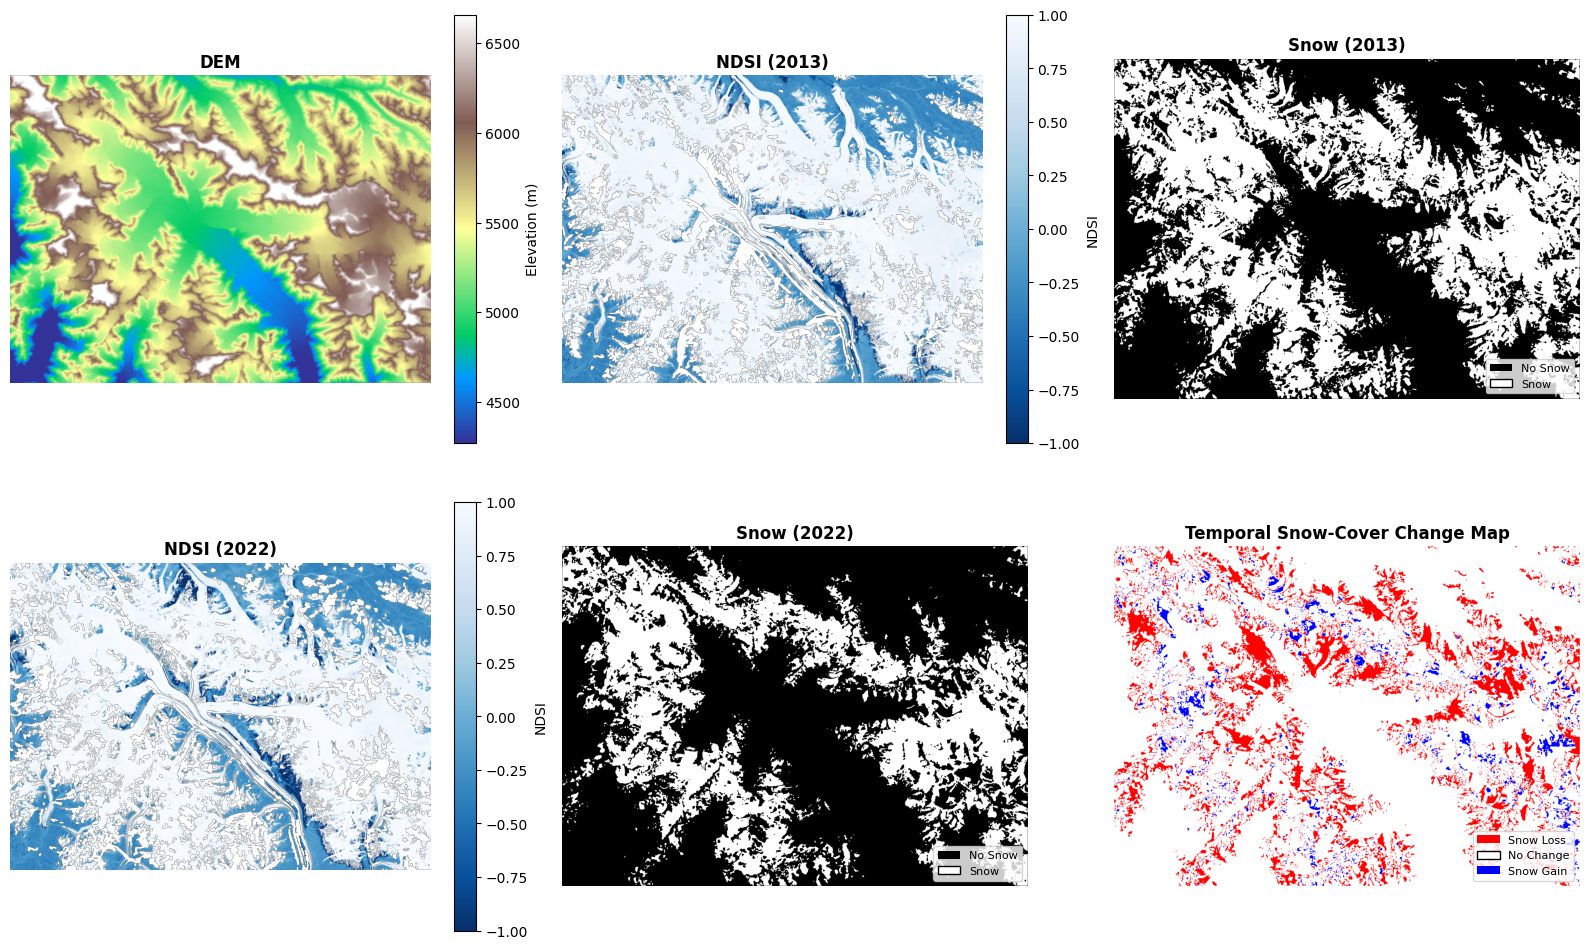

In [105]:
# =============================================================================
# VISUALIZATION OF RESULTS
# =============================================================================

# Create multi-panel figure
fig, axs = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

# =============================================================================
# DEFINE CUSTOM COLORMAPS
# =============================================================================

snow_cmap = ListedColormap([
    "black",   # No snow
    "white"    # Snow
])

change_cmap = ListedColormap([
    "red",     # Snow loss
    "white",   # No change
    "blue"     # Snow gain
])


# =============================================================================
# DIGITAL ELEVATION MODEL (DEM)
# =============================================================================

im0 = axs[0, 0].imshow(
    dem,
    cmap="terrain",
    vmin=np.nanpercentile(dem, 2),
    vmax=np.nanpercentile(dem, 98)
)

axs[0, 0].set_title(
    "DEM",
    fontsize=12,
    fontweight="bold"
)

plt.colorbar(
    im0,
    ax=axs[0, 0],
    fraction=0.046,
    label="Elevation (m)"
)


# =============================================================================
# NDSI MAP — 2013
# =============================================================================

im1 = axs[0, 1].imshow(
    ndsi_2013,
    cmap="Blues_r",
    vmin=-1,
    vmax=1
)

axs[0, 1].set_title(
    "NDSI (2013)",
    fontsize=12,
    fontweight="bold"
)

plt.colorbar(
    im1,
    ax=axs[0, 1],
    fraction=0.046,
    label="NDSI"
)


# =============================================================================
# SNOW CLASSIFICATION — 2013
# =============================================================================

im2 = axs[0, 2].imshow(
    snow_2013,
    cmap=snow_cmap,
    vmin=0,
    vmax=1
)

axs[0, 2].set_title(
    "Snow (2013)",
    fontsize=12,
    fontweight="bold"
)

snow_legend = [
    Patch(facecolor="black", label="No Snow"),
    Patch(facecolor="white", edgecolor="black", label="Snow")
]

axs[0, 2].legend(
    handles=snow_legend,
    loc="lower right",
    fontsize=8,
    frameon=True
)


# =============================================================================
# NDSI MAP — 2022
# =============================================================================

im3 = axs[1, 0].imshow(
    ndsi_2022,
    cmap="Blues_r",
    vmin=-1,
    vmax=1
)

axs[1, 0].set_title(
    "NDSI (2022)",
    fontsize=12,
    fontweight="bold"
)

plt.colorbar(
    im3,
    ax=axs[1, 0],
    fraction=0.046,
    label="NDSI"
)


# =============================================================================
# SNOW CLASSIFICATION — 2022
# =============================================================================

im4 = axs[1, 1].imshow(
    snow_2022,
    cmap=snow_cmap,
    vmin=0,
    vmax=1
)

axs[1, 1].set_title(
    "Snow (2022)",
    fontsize=12,
    fontweight="bold"
)

axs[1, 1].legend(
    handles=snow_legend,
    loc="lower right",
    fontsize=8,
    frameon=True
)


# =============================================================================
# TEMPORAL SNOW-COVER CHANGE MAP
# =============================================================================

im5 = axs[1, 2].imshow(
    change_map,
    cmap=change_cmap,
    vmin=-1,
    vmax=1
)

axs[1, 2].set_title(
    "Temporal Snow-Cover Change Map",
    fontsize=12,
    fontweight="bold"
)

change_legend = [
    Patch(facecolor="red", label="Snow Loss"),
    Patch(facecolor="white", edgecolor="black", label="No Change"),
    Patch(facecolor="blue", label="Snow Gain")
]

axs[1, 2].legend(
    handles=change_legend,
    loc="lower right",
    fontsize=8,
    frameon=True
)


# =============================================================================
# FINAL FIGURE FORMATTING
# =============================================================================

# Remove axis ticks for cleaner visualization
for ax in axs.flat:
    ax.axis("off")

# Adjust subplot spacing
plt.tight_layout()

plt.savefig(
    "outputs/figures/snow_analysis.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Display figure
plt.show()

# Close figure
plt.close()

# **Elevation-wise Snow Distribution Plot**

This plot compares snow distribution across elevation zones for 2013 and 2022.

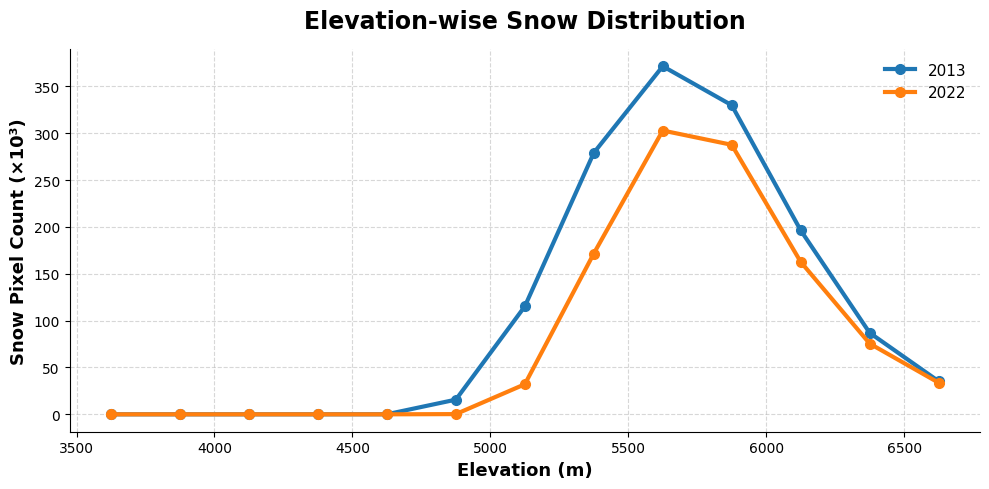

In [106]:
# =============================================================================
# ELEVATION-WISE SNOW DISTRIBUTION PLOT
# =============================================================================

# Create figure
plt.figure(figsize=(10, 5))

# -----------------------------------------------------------------------------
# SNOW DISTRIBUTION — 2013
# -----------------------------------------------------------------------------

plt.plot(
    mid_elevations,
    snow_counts_2013_k,
    marker="o",
    markersize=7,
    linewidth=3,
    label="2013"
)

# -----------------------------------------------------------------------------
# SNOW DISTRIBUTION — 2022
# -----------------------------------------------------------------------------

plt.plot(
    mid_elevations,
    snow_counts_2022_k,
    marker="o",
    markersize=7,
    linewidth=3,
    label="2022"
)

# Axis labels
plt.xlabel(
    "Elevation (m)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Snow Pixel Count (×10³)",
    fontsize=13,
    fontweight="bold"
)

# Plot title
plt.title(
    "Elevation-wise Snow Distribution",
    fontsize=17,
    fontweight="bold",
    pad=15
)

# Grid and legend
plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.legend(
    frameon=False,
    fontsize=11
)

# Axis styling
ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# Save figure
plt.savefig(
    "outputs/figures/elevation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Conclusion**

This notebook demonstrates a complete Python-based workflow for snow-cover delineation and temporal snow-change detection using Landsat 8 imagery and DEM-assisted analysis.

The workflow integrated spectral-index based snow extraction, cloud and cloud-shadow masking, DEM-constrained snow classification, morphological filtering, and elevation-wise snow-distribution assessment to evaluate snow-cover dynamics between 2013 and 2022.

---

## Key Findings

- Snow-covered area decreased from ~1310 km² in 2013 to ~984 km² in 2022.
- Total observed snow-cover reduction was ~326 km².
- Overall snow-cover declined by ~24.9% during the study period.
- Maximum snow concentration was observed within higher elevation zones (~5500–6000 m).

The elevation-wise analysis indicated comparatively greater snow-cover reduction across lower elevation regions, while higher altitude zones retained relatively stable snow persistence.

---

## Future Improvements

Possible future extensions include:

- Sentinel-2 based higher-resolution snow mapping
- Seasonal and multi-temporal snow monitoring
- Machine learning-based snow classification
- Long-term climate trend assessment